# Vol Surface Construction Review

Verify the Bachelier avg-rate pricing pipeline works correctly before running calibration.  
Pricing functions from `caplet_vol_surface.py`.

In [1]:
import pandas as pd, numpy as np, torch
from pathlib import Path
from scipy.stats import norm
import sys, os
sys.path.insert(0, '..')       # docs/quant/affine_calibration  → caplet_vol_surface
sys.path.insert(0, '../..')    # docs/quant     → pyquant
from caplet_vol_surface import (
    bachelier_caplet_price, implied_vol_avg_rate,
    fast_simulate, theta_to_vec, batch_price_caplets, rho_to_vec
)
from pyquant.interest_rates import build_fwd_curve, build_ifwd_curve_from_now_starting
from pyquant.torch_spline import PchipSpline1D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load market data & build curves ──────────────────────────────────────
data_dir = Path('../../../../data')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')
fwd_ois     = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')

key_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32))
ois_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32))
key_ifwd_spline = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32))
ois_ifwd_spline = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32))

# ── Timeline + instantaneous forwards ────────────────────────────────────
T_MAX, N_STEPS = 10.0, 3651
timeline = torch.linspace(0, T_MAX, N_STEPS + 1, dtype=torch.float32, device=device)
dt = timeline[1] - timeline[0]
dt_v = dt.item()

I_key = key_ifwd_spline.evaluate(timeline.cpu()).to(device)
I_ois = ois_ifwd_spline.evaluate(timeline.cpu()).to(device)
f_key_vec = torch.zeros_like(timeline)
f_key_vec[:-1] = torch.diff(I_key) / dt; f_key_vec[-1] = f_key_vec[-2]
f_ois_vec = torch.zeros_like(timeline)
f_ois_vec[:-1] = torch.diff(I_ois) / dt; f_ois_vec[-1] = f_ois_vec[-2]

# ── Caplet grid ───────────────────────────────────────────────────────────
caplet_data = vol_key_rate[['time_to_maturity', 'strike', 'implied_normal_vol']].values
T_fixes  = torch.tensor(caplet_data[:, 0], dtype=torch.float32, device=device)
strikes  = torch.tensor(caplet_data[:, 1], dtype=torch.float32, device=device)
market_vols = torch.tensor(caplet_data[:, 2], dtype=torch.float32, device=device)
idx_fixes = torch.searchsorted(timeline, T_fixes).clamp(0, len(timeline)-1)
idx_pays  = torch.searchsorted(timeline, T_fixes + 0.25).clamp(0, len(timeline)-1)
market_fwds = key_ifwd_spline.evaluate(T_fixes.cpu()).to(device) / T_fixes
market_fwds_period = key_fwd_spline.evaluate(T_fixes.cpu()).to(device)

print(f'Loaded {len(T_fixes)} caplets, device={device}, dt={dt_v*365:.1f} days')

Loaded 495 caplets, device=cuda, dt=1.0 days


## 1. Round-Trip Test: σ → Price → σ

In [2]:
# Round-trip at ACTUAL market strikes (near ATM) for each maturity
print(f"{'T':>6s} {'K':>6s} {'F':>7s} {'σ_in':>7s} {'PV(bp)':>10s} {'σ_out':>10s} {'err':>10s}")
print('-' * 65)

# Pick mid-strike caplet for each unique maturity
for T_test in sorted(set(T_fixes.cpu().numpy())):
    mask = (T_fixes - T_test).abs() < 0.01
    idxs = mask.nonzero().squeeze()
    if idxs.dim() == 0: idxs = idxs.unsqueeze(0)
    ci = idxs[len(idxs)//2].item()  # mid-strike ≈ ATM
    T = T_fixes[ci].item(); K = strikes[ci].item(); F = market_fwds[ci].item()
    sigma_in = market_vols[ci].item()
    idx_T_ = min(int(T / dt_v), len(f_ois_vec) - 1)
    disc = torch.exp(-f_ois_vec[:idx_T_+1].sum() * dt_v).item()
    pv = bachelier_caplet_price(F, K, T, sigma_in, disc)
    sigma_out = implied_vol_avg_rate(F, K, T, pv, disc)
    err = abs(sigma_out - sigma_in) if not np.isnan(sigma_out) else float('nan')
    lbl = f'{T:.1f}Y' if T >= 1 else f'{T*12:.0f}M'
    print(f"{lbl:>6s} {K*100:>5.0f}% {F*100:>6.1f}% {sigma_in*100:>6.2f}% {pv*10000:>9.4f} "
          f"{sigma_out*100:>9.6f}% {err:.2e}")

     T      K       F    σ_in     PV(bp)      σ_out        err
-----------------------------------------------------------------
    1M    12%   15.9%   2.80%   27.8496  2.803751% 3.49e-06
    2M    12%   15.8%   2.54%   54.2658  2.544200% 1.58e-10
    3M    12%   15.8%   2.22%   79.3690  2.221600% 2.71e-11
    6M    12%   15.7%   2.64%  147.8453  2.643100% 1.26e-10
    9M    12%   14.8%   3.22%  159.1240  3.221500% 1.30e-13
  1.0Y    12%   14.1%   3.38%  159.8334  3.384000% 2.14e-12
  2.0Y    12%   12.0%   3.31%  131.2510  3.315000% 1.46e-14
  3.0Y    12%   10.9%   3.13%  133.3883  3.132500% 9.02e-17
  4.0Y    12%   10.2%   3.01%  141.5906  3.011000% 1.88e-14
  5.0Y    12%    9.6%   2.90%  148.2781  2.897900% 8.67e-17
  6.0Y    12%    9.2%   2.81%  156.2018  2.813600% 3.74e-12
  7.0Y    12%    8.8%   2.74%  163.3009  2.743000% 1.89e-13
  8.0Y    12%    8.4%   2.70%  174.1895  2.702900% 2.33e-11
  9.0Y    12%    8.1%   2.67%  185.2689  2.670300% 4.51e-17
 10.0Y    12%    7.9%   2.63%  

Round-trip: 495/495 valid | Max err: 0.000000% | RMSE: 0.00000001%


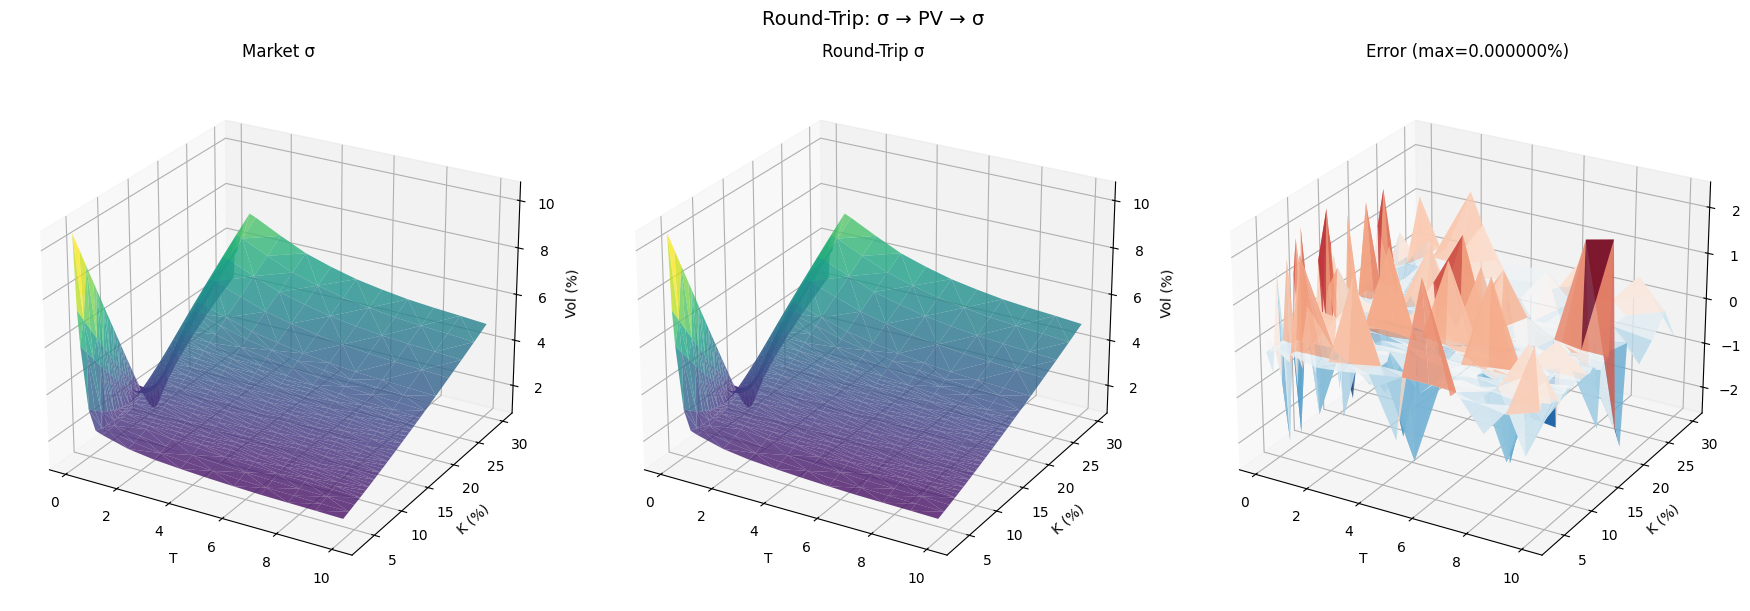

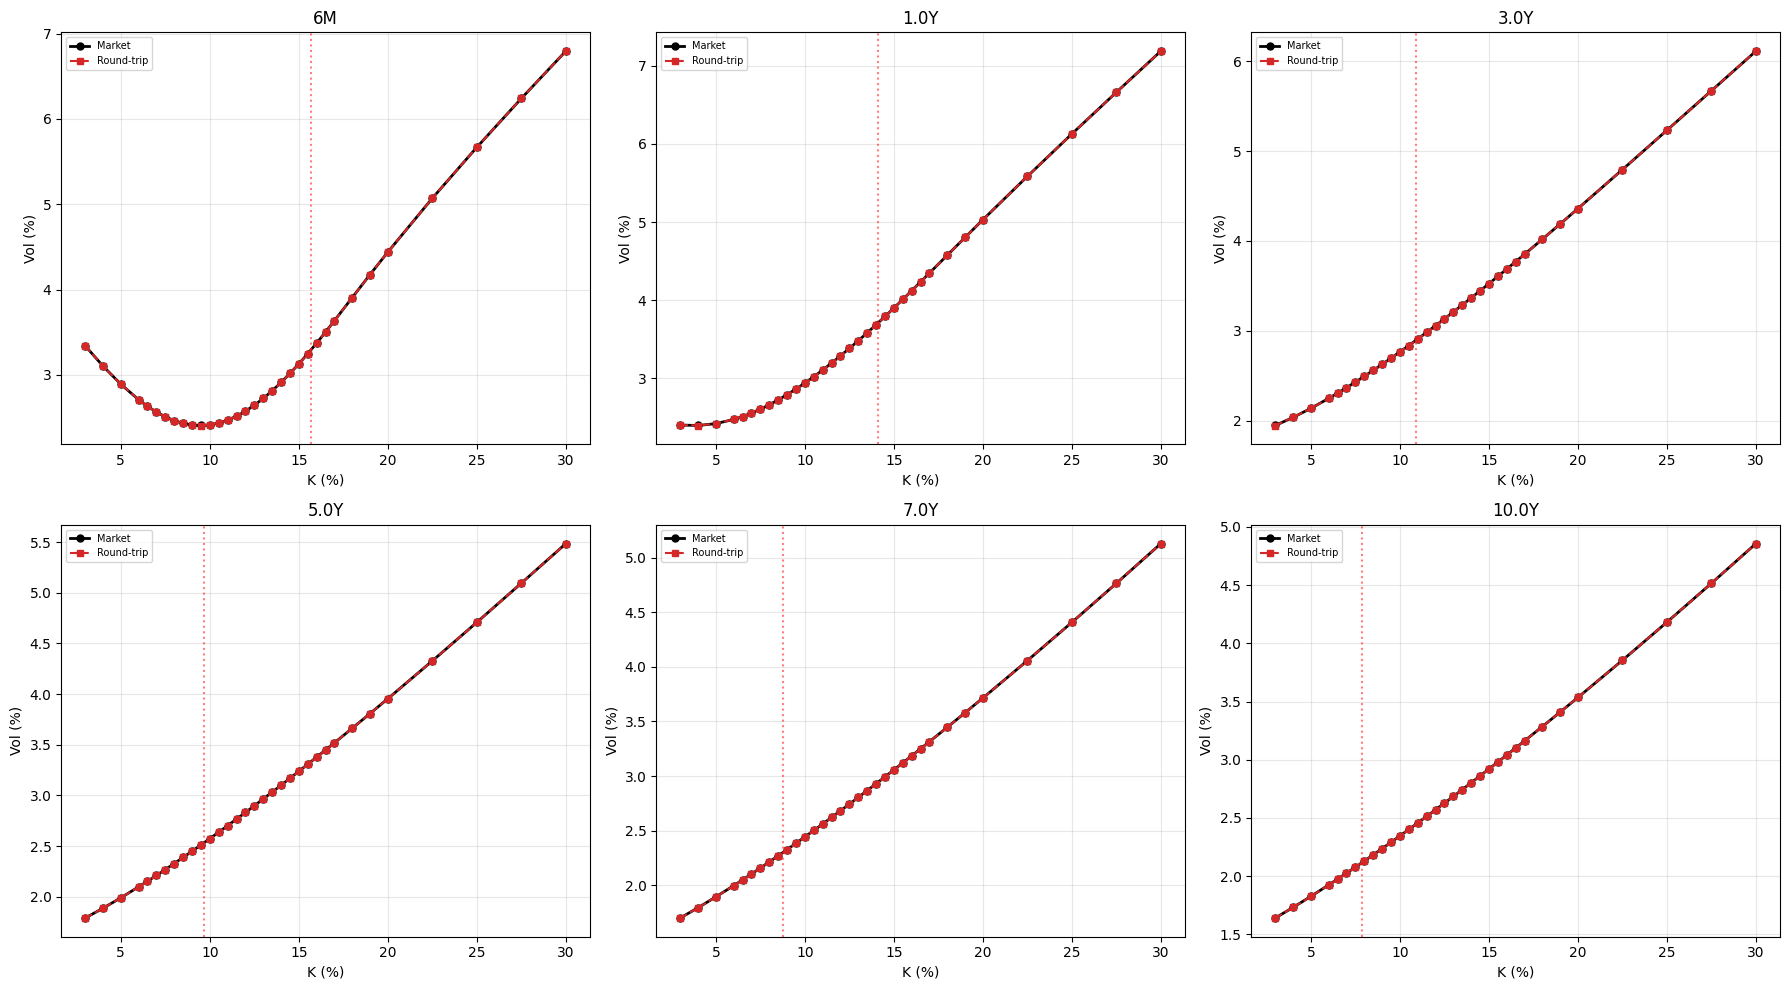

In [3]:
import importlib, matplotlib.pyplot as plt
import caplet_vol_surface as _cvs; importlib.reload(_cvs)
from caplet_vol_surface import (bachelier_caplet_price, bachelier_caplet_time_value,
                                 implied_vol_from_tv, generate_caplet_vol_surface)
from scipy.interpolate import PchipInterpolator

_fwd_sorted = fwd_key_rate.sort_values('time_to_maturity')
_fwd_interp = PchipInterpolator(_fwd_sorted['time_to_maturity'].values,
                                 _fwd_sorted['forward_rate'].values)
_ois_sorted = fwd_ois.sort_values('time_to_maturity')
_ois_interp = PchipInterpolator(_ois_sorted['time_to_maturity'].values,
                                 _ois_sorted['forward_rate'].values)

def _avg_inst_fwd(T):
    F_period = float(_fwd_interp(T))
    return -np.log(max(1.0 / (1.0 + T * F_period), 1e-15)) / max(T, 1e-10)

def _ois_disc(T):
    return 1.0 / (1.0 + T * float(_ois_interp(T)))

# ── Per-caplet round-trip via TV channel ──────────────────────────────────
rt_records = []
for _, row in vol_key_rate.iterrows():
    T, K, sigma_in = row['time_to_maturity'], row['strike'], row['implied_normal_vol']
    F, disc = _avg_inst_fwd(T), _ois_disc(T)
    pv = bachelier_caplet_price(F, K, T, sigma_in, disc)
    tv = bachelier_caplet_time_value(F, K, T, sigma_in, disc)
    sigma_out = implied_vol_from_tv(F, K, T, tv, disc)
    method = 'TV'
    if np.isnan(sigma_out):
        sigma_out = implied_vol_avg_rate(F, K, T, pv, disc)
        method = 'PV'
    rt_records.append({
        'time_to_maturity': T, 'strike': K, 'implied_normal_vol': sigma_in,
        'F_avg': F, 'sigma_out': sigma_out, 'pv': pv,
        'err': abs(sigma_out - sigma_in) if not np.isnan(sigma_out) else np.nan,
    })

vr_rt = pd.DataFrame(rt_records)
valid = ~np.isnan(vr_rt['err'])
print(f"Round-trip: {valid.sum()}/{len(vr_rt)} valid | "
      f"Max err: {vr_rt.loc[valid,'err'].max()*100:.6f}% | "
      f"RMSE: {np.sqrt((vr_rt.loc[valid,'err']**2).mean())*100:.8f}%")

# ── 3D surfaces ───────────────────────────────────────────────────────────
vr_rt_surf = vr_rt.copy()
vr_rt_surf['rt_vol'] = vr_rt['sigma_out']

fig = plt.figure(figsize=(18, 6))
for pidx, (col, title) in enumerate([
    ('implied_normal_vol', 'Market σ'), ('rt_vol', 'Round-Trip σ')]):
    ax = fig.add_subplot(1, 3, pidx + 1, projection='3d')
    sub = vr_rt_surf[~np.isnan(vr_rt_surf[col])]
    ax.plot_trisurf(sub['time_to_maturity'].values, sub['strike'].values * 100,
                    sub[col].values * 100, cmap='viridis', alpha=0.8, edgecolor='none')
    ax.set_xlabel('T'); ax.set_ylabel('K (%)'); ax.set_zlabel('Vol (%)'); ax.set_title(title)
    ax.view_init(elev=25, azim=-60)
ax = fig.add_subplot(1, 3, 3, projection='3d')
vs = vr_rt_surf.dropna(subset=['rt_vol', 'implied_normal_vol'])
errs = (vs['rt_vol'] - vs['implied_normal_vol']) * 100
ax.plot_trisurf(vs['time_to_maturity'].values, vs['strike'].values * 100,
                errs.values, cmap='RdBu_r', alpha=0.8, edgecolor='none')
ax.set_xlabel('T'); ax.set_ylabel('K (%)'); ax.set_zlabel('Err (%)')
ax.set_title(f'Error (max={errs.abs().max():.6f}%)'); ax.view_init(elev=25, azim=-60)
plt.suptitle('Round-Trip: σ → PV → σ', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# ── Smile slices ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx_p, T_m in enumerate([0.5, 1.0, 3.0, 5.0, 7.0, 10.0]):
    ax = axes[idx_p // 3, idx_p % 3]
    sub = vr_rt_surf[np.abs(vr_rt_surf['time_to_maturity'] - T_m) < 0.05].sort_values('strike')
    if len(sub) == 0: continue
    ax.plot(sub['strike']*100, sub['implied_normal_vol']*100, 'o-', color='black', lw=2, ms=5, label='Market')
    v = ~np.isnan(sub['rt_vol'])
    ax.plot(sub.loc[v, 'strike']*100, sub.loc[v, 'rt_vol']*100, 's--', color='tab:red', lw=1.5, ms=4, label='Round-trip')
    ax.axvline(_avg_inst_fwd(T_m)*100, color='red', ls=':', alpha=0.5)
    lbl = f'{T_m:.1f}Y' if T_m >= 1 else f'{T_m*12:.0f}M'
    ax.set_title(lbl); ax.set_xlabel('K (%)'); ax.set_ylabel('Vol (%)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Forward Rate: $F_{\text{avg}}$ vs $F_{\text{period}}$

MC and calibration use $F_{\text{avg}}(T) = I(0,T)/T$ (average instantaneous forward), not the simple period rate $F_{\text{period}}$.

In [4]:
# F_period vs F_avg across maturities
print(f"{'T':>6s} {'F_period':>10s} {'F_avg':>10s} {'gap':>8s}")
print('-' * 38)
for T_v in [0.083, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]:
    mask = (T_fixes - T_v).abs() < 0.02
    if not mask.any(): continue
    idx_t = mask.nonzero()[0][0].item()
    fp = market_fwds_period[idx_t].item()
    fa = market_fwds[idx_t].item()
    lbl = f'{T_v:.1f}Y' if T_v >= 1 else f'{T_v*12:.0f}M'
    print(f"{lbl:>6s} {fp*100:>9.2f}% {fa*100:>9.2f}% {(fa-fp)*100:>+7.2f}%")

     T   F_period      F_avg      gap
--------------------------------------
    1M     16.02%     15.89%   -0.13%
    3M     16.12%     15.80%   -0.32%
    6M     16.33%     15.70%   -0.63%
  1.0Y     15.16%     14.12%   -1.04%
  2.0Y     13.52%     11.97%   -1.55%
  3.0Y     12.93%     10.93%   -2.00%
  5.0Y     12.40%      9.65%   -2.75%
  7.0Y     12.14%      8.79%   -3.35%
 10.0Y     11.94%      7.86%   -4.08%


## 3. MC Vol Surface vs Market

MC simulation with SPSA v6 parameters, compare implied vol surface to market.

In [5]:
import gc, time

# ── θ nodes & SPSA v6 parameters ─────────────────────────────────────────
theta_nodes_t = torch.tensor([0.0, 0.25, 0.5, 1.0, 3.0, 5.0, 10.0], dtype=torch.float32, device=device)
_mkt_T_np, _mkt_K_np, _mkt_vols_np = caplet_data[:, 0], caplet_data[:, 1], caplet_data[:, 2]

lam_init, kappa_init, eps_init = 0.219, 3.25, 0.274
gamma_init, xi_init, rho_vx_init = 0.5, 0.01, 0.267

def ou_avg_rate_correction(lam, T):
    if lam * T < 1e-6: return 1.0
    t1 = T / (lam ** 2)
    t2 = 2.0 * (1.0 - np.exp(-lam * T)) / (lam ** 3)
    t3 = (1.0 - np.exp(-2.0 * lam * T)) / (2.0 * lam ** 3)
    return (3.0 / T ** 3) * (t1 - t2 + t3)

# ── Solve θ(T) = σ²_ATM / corr(λ, T) ────────────────────────────────────
theta_init_list = []
for tn in theta_nodes_t.cpu().numpy():
    T_eff = max(tn, 0.01)
    F_tn = key_ifwd_spline.evaluate(torch.tensor([T_eff])).item() / T_eff
    mask_t = np.abs(_mkt_T_np - tn) < max(0.15, max(tn, 0.1) * 0.3)
    if mask_t.sum() > 0:
        sigma_target = _mkt_vols_np[np.where(mask_t)[0][np.argmin(np.abs(_mkt_K_np[mask_t] - F_tn))]]
    else:
        sigma_target = np.median(_mkt_vols_np)
    theta_init_list.append(np.clip(sigma_target ** 2 / max(ou_avg_rate_correction(lam_init, T_eff), 0.01), 0.0002, 0.05))
theta_init_list[0] = theta_init_list[1]  # anchor t=0

theta_init = torch.tensor(theta_init_list, dtype=torch.float32, device=device)
theta_vec_init = theta_to_vec(theta_init, theta_nodes_t, timeline)
v0_init = theta_init_list[0]
corrs = [ou_avg_rate_correction(lam_init, max(t, 0.01)) for t in theta_nodes_t.cpu().numpy()]

# ── MC: 100k paths ───────────────────────────────────────────────────────
t0 = time.time()
key_paths_init, ois_paths_init, v_paths_init = fast_simulate(
    100000, timeline, theta_vec_init, eps_init, v0_init, kappa_init, lam_init,
    gamma_init, xi_init, f_key_vec, f_ois_vec, device,
    seed=42, rho_vx=rho_vx_init, antithetic=True
)
model_pvs_init, F_model_init, P_model_init = batch_price_caplets(
    key_paths_init, ois_paths_init, timeline, idx_fixes, idx_pays, strikes, 0.25, device
)
print(f"MC done in {time.time()-t0:.1f}s | PV range: [{model_pvs_init.min().item():.6f}, {model_pvs_init.max().item():.6f}]")

del key_paths_init, ois_paths_init, v_paths_init
gc.collect(); torch.cuda.empty_cache()

MC done in 0.8s | PV range: [0.000000, 0.187984]


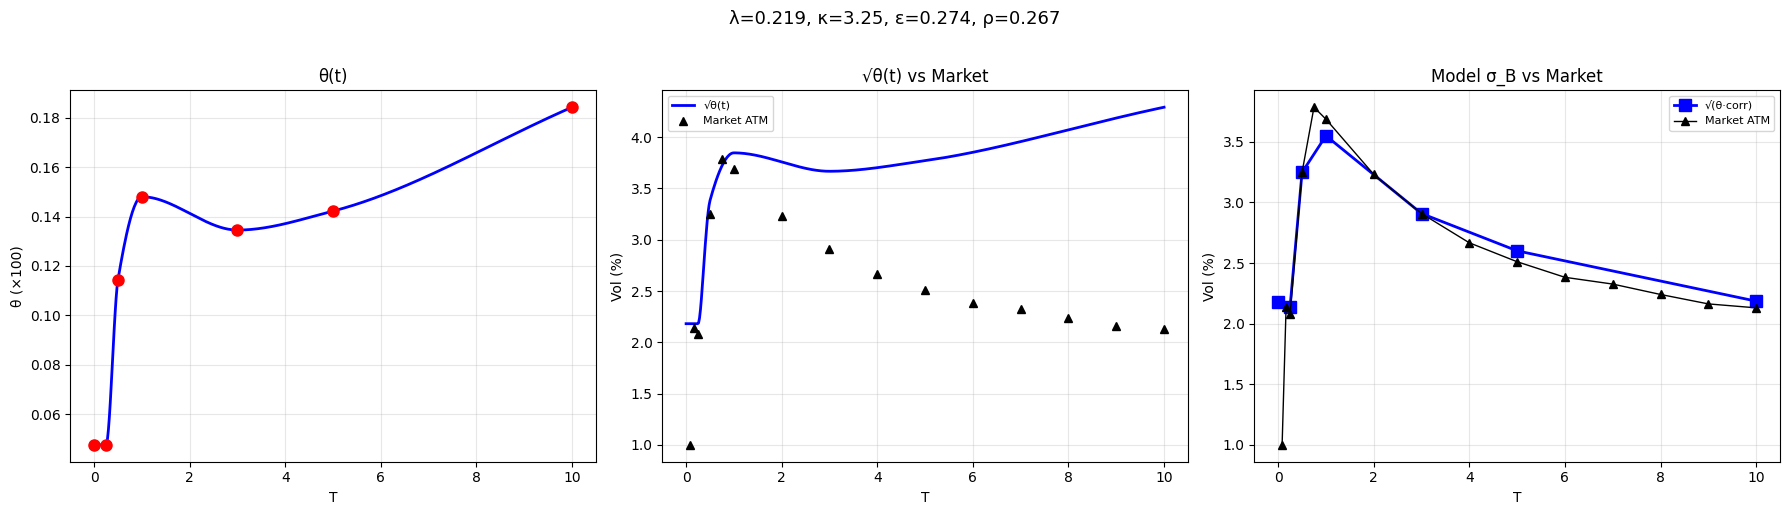

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# θ(t) spline
t_fine = torch.linspace(0, float(timeline[-1]), 500, device=device)
theta_spline = PchipSpline1D(theta_nodes_t, theta_init)
theta_fine = theta_spline.evaluate(t_fine).detach().cpu().numpy()
t_fine_np = t_fine.cpu().numpy()
tn_np = theta_nodes_t.cpu().numpy()

axes[0].plot(t_fine_np, theta_fine * 100, 'b-', lw=2)
axes[0].plot(tn_np, np.array(theta_init_list) * 100, 'ro', ms=8)
axes[0].set_title('θ(t)'); axes[0].set_xlabel('T'); axes[0].set_ylabel('θ (×100)'); axes[0].grid(alpha=0.3)

# √θ(t) vs market ATM
axes[1].plot(t_fine_np, np.sqrt(np.maximum(theta_fine, 0)) * 100, 'b-', lw=2, label='√θ(t)')
atm_Ts, atm_vols = [], []
for T_m in sorted(np.unique(_mkt_T_np)):
    F_T = key_ifwd_spline.evaluate(torch.tensor([T_m])).item() / T_m
    mask = np.abs(_mkt_T_np - T_m) < 0.01
    if mask.sum() > 0:
        atm_vols.append(_mkt_vols_np[np.where(mask)[0][np.argmin(np.abs(_mkt_K_np[mask] - F_T))]])
        atm_Ts.append(T_m)
axes[1].plot(atm_Ts, np.array(atm_vols) * 100, 'k^', ms=6, label='Market ATM')
axes[1].set_title('√θ(t) vs Market'); axes[1].set_xlabel('T'); axes[1].set_ylabel('Vol (%)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# σ_B = √(θ·corr) vs market ATM
pred_vols = np.sqrt(np.array(theta_init_list) * np.array(corrs)) * 100
axes[2].plot(tn_np, pred_vols, 'bs-', ms=8, lw=2, label='√(θ·corr)')
axes[2].plot(atm_Ts, np.array(atm_vols) * 100, 'k^-', ms=6, lw=1, label='Market ATM')
axes[2].set_title('Model σ_B vs Market'); axes[2].set_xlabel('T'); axes[2].set_ylabel('Vol (%)')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(f'λ={lam_init}, κ={kappa_init}, ε={eps_init}, ρ={rho_vx_init}', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### Model vs Market Vol Surface


V6 VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid vol inversions: 482 (97.4%)
Failed inversions:    13
Sub-intrinsic (conv): 0 (MC price < det. intrinsic → NaN)
Vol RMSE:             5.880%
Model vol range:      2.50% - 51.16%
Market vol range:     0.97% - 10.58%



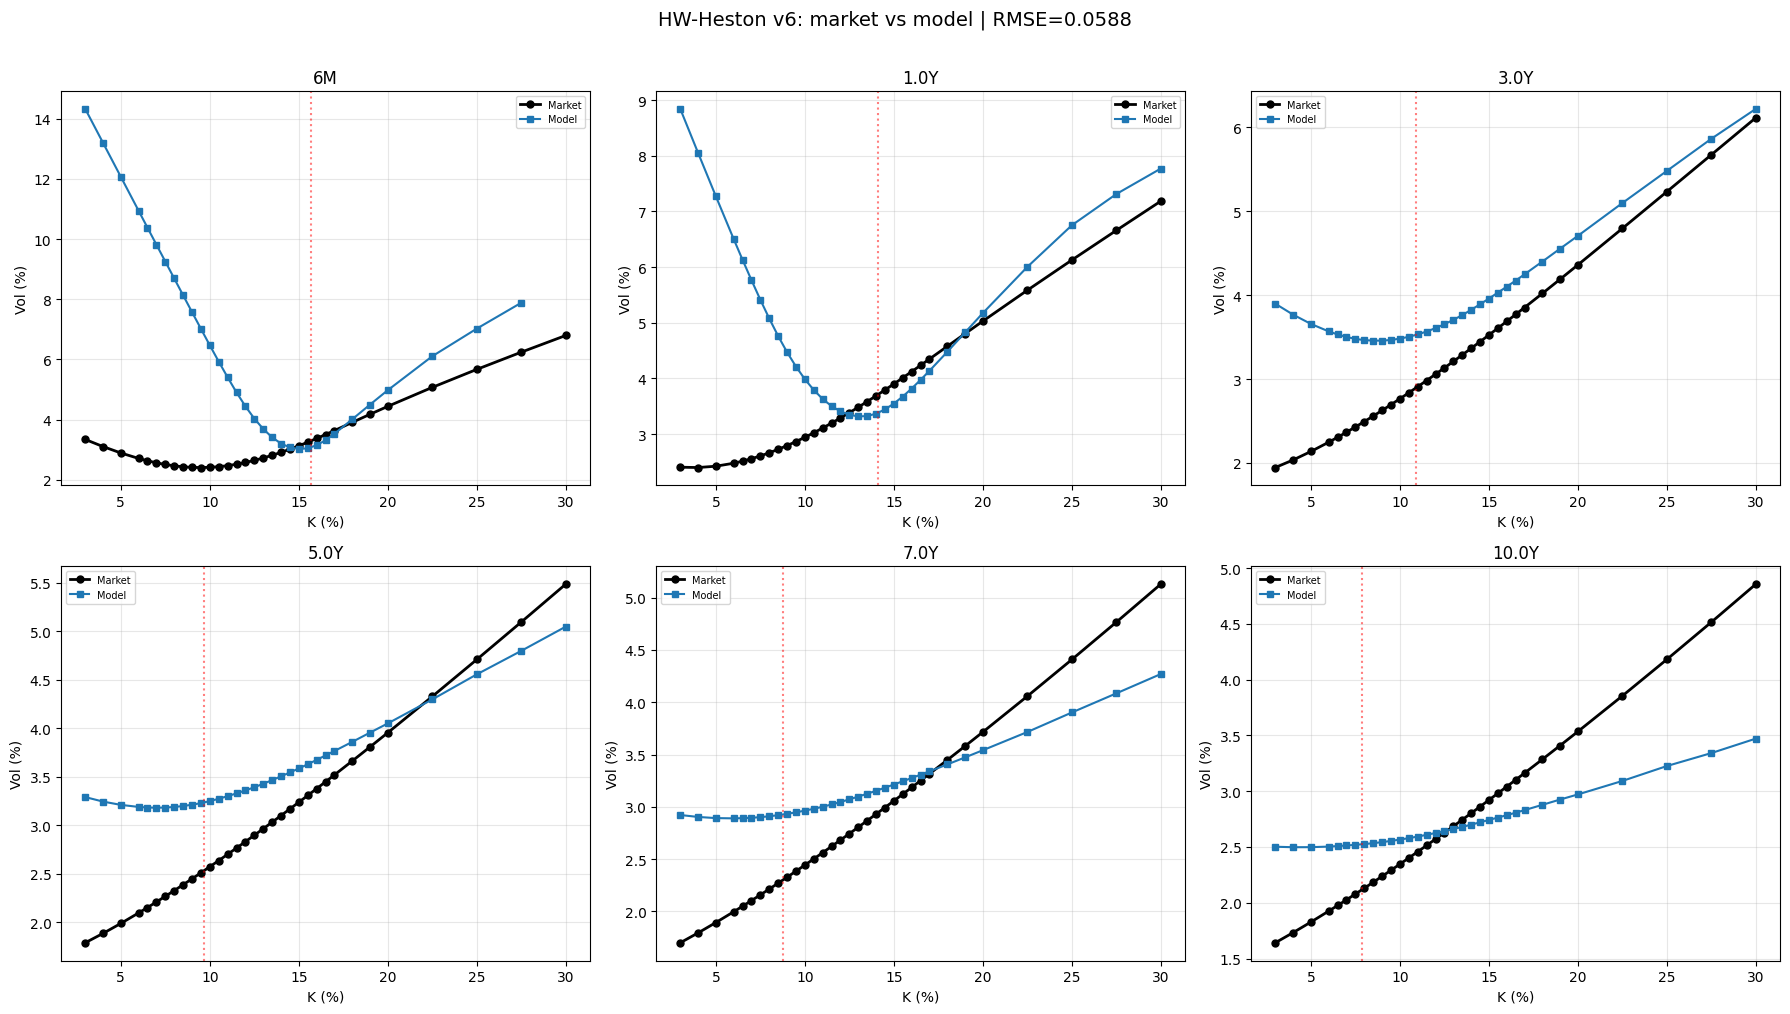

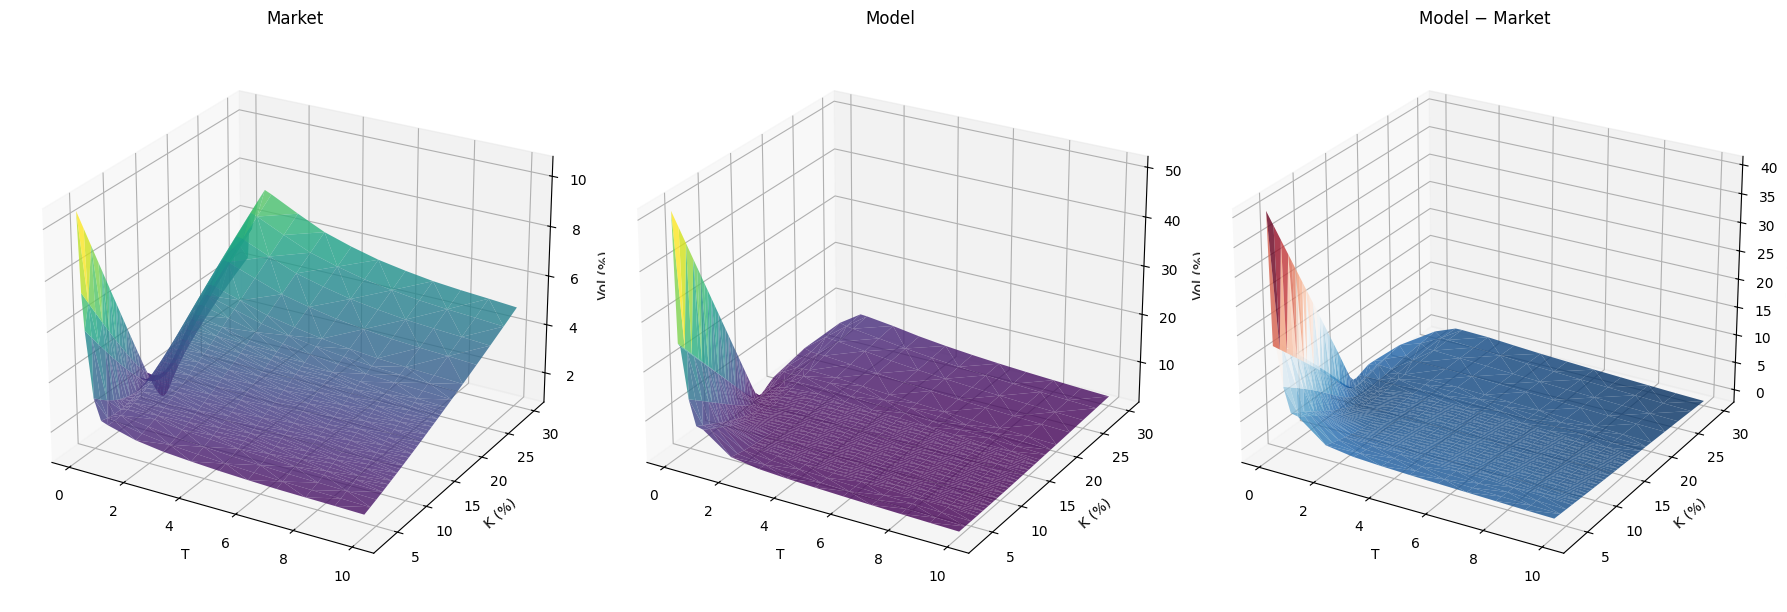

     T     Mkt     Mdl     Err
------------------------------
    1M   1.00%   2.55%  +1.55%
    2M   2.14%   2.69%  +0.55%
    3M   2.08%   2.86%  +0.78%
    6M   3.25%   3.05%  -0.20%
    9M   3.79%   3.28%  -0.51%
  1.0Y   3.69%   3.37%  -0.32%
  2.0Y   3.23%   3.58%  +0.35%
  3.0Y   2.91%   3.53%  +0.62%
  4.0Y   2.67%   3.38%  +0.72%
  5.0Y   2.51%   3.23%  +0.72%
  6.0Y   2.38%   3.07%  +0.69%
  7.0Y   2.33%   2.93%  +0.61%
  8.0Y   2.24%   2.79%  +0.55%
  9.0Y   2.16%   2.65%  +0.49%
 10.0Y   2.13%   2.53%  +0.40%

RMSE: 5.880%


In [7]:
import importlib, matplotlib.pyplot as plt
import caplet_vol_surface as _cvs; importlib.reload(_cvs)
from caplet_vol_surface import generate_caplet_vol_surface

vol_key_rate_init = vol_key_rate.copy()
vol_key_rate_init['pv_model_key'] = model_pvs_init.cpu().numpy()
vol_results_init, vol_rmse_init = generate_caplet_vol_surface(
    vol_key_rate_init, fwd_key_rate, fwd_ois=fwd_ois, version_name="v6",
    F_model=F_model_init.cpu().numpy(), P_model=P_model_init.cpu().numpy()
)

vr = vol_results_init.copy()
model_col = 'model_vol_v6'

# ── Smile slices ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx_p, T_m in enumerate([0.5, 1.0, 3.0, 5.0, 7.0, 10.0]):
    ax = axes[idx_p // 3, idx_p % 3]
    sub = vr[np.abs(vr['time_to_maturity'] - T_m) < 0.05].sort_values('strike')
    if len(sub) == 0: continue
    ax.plot(sub['strike']*100, sub['implied_normal_vol']*100, 'o-', color='black', lw=2, ms=5, label='Market')
    v = ~np.isnan(sub[model_col])
    ax.plot(sub.loc[v, 'strike']*100, sub.loc[v, model_col]*100, 's-', color='tab:blue', lw=1.5, ms=4, label='Model')
    F_T = key_ifwd_spline.evaluate(torch.tensor([T_m])).item() / T_m
    ax.axvline(F_T*100, color='red', ls=':', alpha=0.5)
    lbl = f'{T_m:.1f}Y' if T_m >= 1 else f'{T_m*12:.0f}M'
    ax.set_title(lbl); ax.set_xlabel('K (%)'); ax.set_ylabel('Vol (%)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle(f'HW-Heston v6: market vs model | RMSE={vol_rmse_init:.4f}', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# ── 3D surfaces ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
for pidx, (col, title) in enumerate([('implied_normal_vol', 'Market'), (model_col, 'Model')]):
    ax = fig.add_subplot(1, 3, pidx + 1, projection='3d')
    s = vr.dropna(subset=[col])
    ax.plot_trisurf(s['time_to_maturity'].values, s['strike'].values*100, s[col].values*100,
                    cmap='viridis', alpha=0.8, edgecolor='none')
    ax.set_xlabel('T'); ax.set_ylabel('K (%)'); ax.set_zlabel('Vol (%)'); ax.set_title(title)
    ax.view_init(elev=25, azim=-60)
ax = fig.add_subplot(1, 3, 3, projection='3d')
s = vr.dropna(subset=[model_col, 'implied_normal_vol'])
e = (s[model_col] - s['implied_normal_vol']) * 100
ax.plot_trisurf(s['time_to_maturity'].values, s['strike'].values*100, e.values,
                cmap='RdBu_r', alpha=0.8, edgecolor='none')
ax.set_xlabel('T'); ax.set_ylabel('K (%)'); ax.set_zlabel('Err (%)'); ax.set_title('Model − Market')
ax.view_init(elev=25, azim=-60)
plt.tight_layout(); plt.show()

# ── ATM comparison ────────────────────────────────────────────────────────
print(f"{'T':>6s} {'Mkt':>7s} {'Mdl':>7s} {'Err':>7s}")
print("-" * 30)
for T_m in sorted(vr['time_to_maturity'].unique()):
    sub = vr[np.abs(vr['time_to_maturity'] - T_m) < 0.01]
    F_T = key_ifwd_spline.evaluate(torch.tensor([T_m])).item() / T_m
    mkt = sub.loc[(sub['strike'] - F_T).abs().idxmin(), 'implied_normal_vol'] * 100
    vs = sub[~np.isnan(sub[model_col])]
    mdl = vs.loc[(vs['strike'] - F_T).abs().idxmin(), model_col] * 100 if len(vs) > 0 else np.nan
    lbl = f'{T_m:.1f}Y' if T_m >= 1 else f'{T_m*12:.0f}M'
    print(f"{lbl:>6s} {mkt:>6.2f}% {mdl:>6.2f}% {mdl-mkt:>+6.2f}%")
print(f"\nRMSE: {vol_rmse_init*100:.3f}%")